In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
#CARGAR ARCHIVOS desde Drive

from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

#Read from drive
path = '/content/drive/MyDrive/FISICA COMPUTACIONAL/'
filename1 = 'millas_por_galon.csv'

#para leer

df = pd.read_csv(path+filename1)
df2= df.loc[:,['mpg','horsepower']]

Mounted at /content/drive


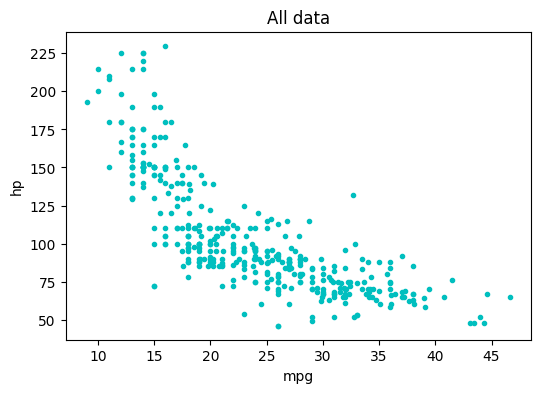

In [4]:

plt.figure(figsize=(6,4))
plt.plot(df2["mpg"], df2["horsepower"],'c.')
plt.xlabel("mpg")
plt.ylabel("hp")
plt.title('All data')
#plt.grid()
plt.show()

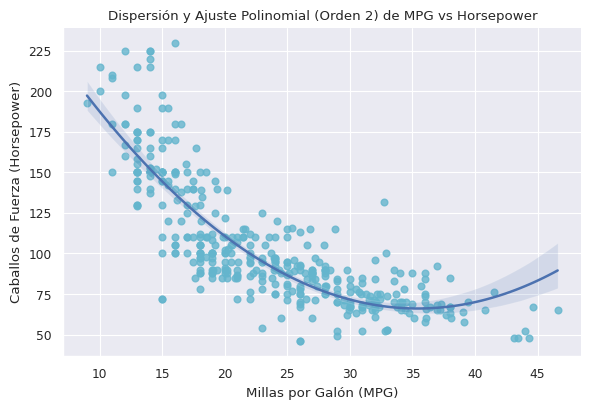

In [5]:
sns.set_theme(context="paper")
DF = df2
g = sns.lmplot(
    data=DF,
    x="mpg", y="horsepower", # Usar columnas de df2
    scatter_kws={'color': 'c'},
    order=2, # ajuste polinomial de orden 2
    height=4, aspect=1.5, ci= 95)
plt.title('Dispersión y Ajuste Polinomial (Orden 2) de MPG vs Horsepower')
plt.xlabel('Millas por Galón (MPG)')
plt.ylabel('Caballos de Fuerza (Horsepower)')
plt.show()

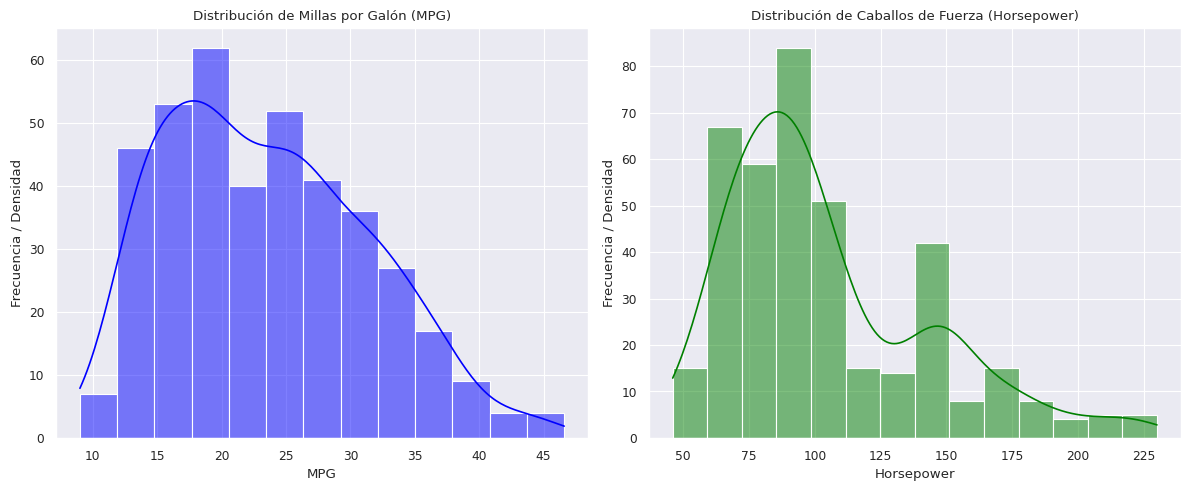

In [6]:
plt.figure(figsize=(12, 5))

# Histograma y KDE para 'mpg'
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(DF['mpg'], kde=True, color='blue')
plt.title('Distribución de Millas por Galón (MPG)')
plt.xlabel('MPG')
plt.ylabel('Frecuencia / Densidad')

# Histograma y KDE para 'horsepower'
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.histplot(DF['horsepower'], kde=True, color='green')
plt.title('Distribución de Caballos de Fuerza (Horsepower)')
plt.xlabel('Horsepower')
plt.ylabel('Frecuencia / Densidad')

plt.tight_layout()
plt.show()

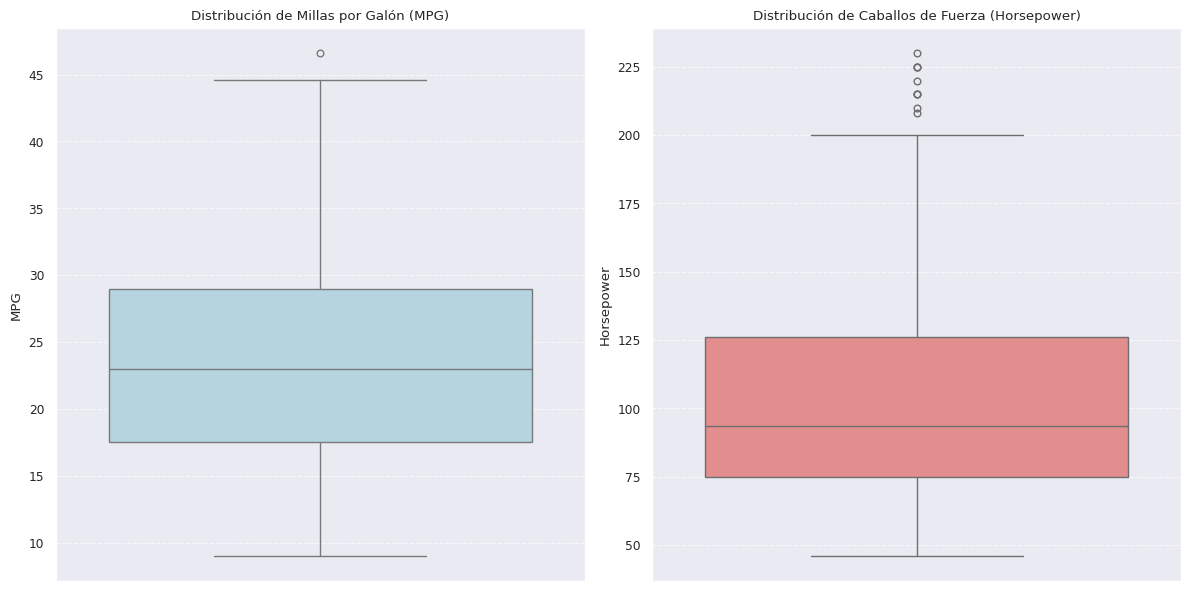

In [7]:
plt.figure(figsize=(12, 6))

# Boxplot para MPG
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.boxplot(y=DF['mpg'], color='lightblue')
plt.title('Distribución de Millas por Galón (MPG)')
plt.ylabel('MPG')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Boxplot para Horsepower
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(y=DF['horsepower'], color='lightcoral')
plt.title('Distribución de Caballos de Fuerza (Horsepower)')
plt.ylabel('Horsepower')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##ANALISIS ESTADISTICO

Al analizar la relación entre la potencia (Horsepower) y el rendimiento (MPG), queda claro que a mayor cantidad de caballos de fuerza, el consumo de combustible aumenta, aunque no de forma constante; de hecho, esta curva no lineal sugiere que un modelo polinomial refleja mucho mejor la realidad que una simple línea recta. Al mirar cómo se distribuyen los datos, ambas variables muestran un sesgo hacia la derecha: en el caso del rendimiento, la mayoría de los vehículos se concentran alrededor de las 22 a 23 MPG (con solo unos pocos modelos extremadamente eficientes), mientras que en la potencia la gran masa de autos se ubica entre los 90 y 100 HP, dejando los valores más altos para una minoría de vehículos de gran desempeño que claramente se salen de la norma.

#2

In [13]:
path = '/content/drive/MyDrive/FISICA COMPUTACIONAL/'
filename2 = 'general-scan.csv'

#para leer

dfM = pd.read_csv(path+filename2)

In [14]:
dfM

,Unnamed: 0,MDF,MS12,MS22,LamS1H,LamS2H,LamSPH,LamS,LamSP,vS,...,U,mueg,taumug,sv,ZH11,ZH12,ZH21,ZH22,BRh1gg,BRh2gg
0,0,396.848661,2.137304e+06,2.137304e+06,0.020984,0.020984,0.020052,0.000000,0.217236,702.109163,...,0.001075,0.0,1.773785e-19,1.860000e-26,0.999293,-0.037599,0.037599,0.999293,0.002837,0.000000
1,1,5988.499243,1.889315e+07,1.889315e+07,0.023341,0.023341,0.000181,0.000000,0.019173,329.668504,...,-0.002513,0.0,1.791040e-18,2.580000e-31,0.001084,-0.999999,-0.999999,-0.001084,0.000342,0.002816
2,2,452.875632,2.469280e+06,2.469280e+06,0.000490,0.000490,0.017861,0.000000,0.337367,3843.138599,...,0.000638,0.0,4.833919e-18,1.220000e-26,0.999994,-0.003384,0.003384,0.999994,0.002822,0.000000
3,3,589.443344,9.826674e+07,9.826674e+07,0.042790,0.042790,0.031174,0.000000,0.270921,314.258778,...,0.000181,0.0,9.406560e-16,2.740000e-30,0.979480,-0.201541,0.201541,0.979480,0.002838,0.000194
4,4,1092.250036,2.054042e+06,2.054042e+06,0.002196,0.002196,0.002346,0.000000,0.046671,13048.623894,...,0.000066,0.0,1.002187e-13,1.970000e-26,1.000000,-0.000945,0.000945,1.000000,0.002827,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17391,19,1117.302129,2.175653e+06,2.175653e+06,0.008842,0.008842,0.000272,0.201033,0.001103,27580.576196,...,0.000063,0.0,3.277485e-15,1.930000e-26,0.999998,-0.002229,0.002229,0.999998,0.002827,0.000000
17392,20,1134.026597,2.092129e+06,2.092129e+06,0.090092,0.090092,0.000389,0.001842,0.463102,5738.478616,...,0.000061,0.0,2.432178e-13,1.940000e-26,1.000000,-0.000036,0.000036,1.000000,0.002827,0.000000
17393,21,1135.029100,2.819239e+07,2.819239e+07,0.008246,0.008246,0.001548,0.038374,1.342324,44788.888482,...,0.000061,0.0,2.842254e-18,1.890000e-26,1.000000,-0.000006,0.000006,1.000000,0.002827,0.000000
17394,22,4256.415506,1.462197e+06,1.462197e+06,0.014256,0.014256,0.001920,0.002212,0.159277,428.133858,...,0.000004,0.0,3.530488e-26,2.220000e-30,0.999891,-0.014794,0.014794,0.999891,0.002819,0.000140


In [35]:
OMji= dfM['Omega']
OMji

,Omega
0,0.135
1,0.127
2,0.133
3,0.139
4,0.119
...,...
17391,0.118
17392,0.125
17393,0.122
17394,0.115


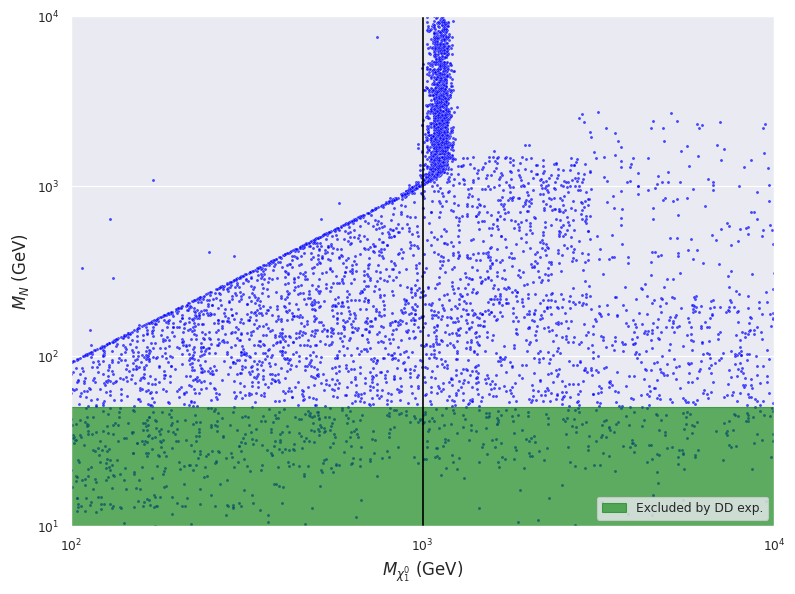

In [41]:
Y = dfM['YRC'] * dfM['vS'] / np.sqrt(2)
X = dfM['MDF']

# Create a temporary DataFrame for seaborn
plot_df = pd.DataFrame({'X': X, 'Y': Y})

plt.figure(figsize=(8, 6)) # Create a figure for better control

sns.scatterplot(data=plot_df, x='X', y='Y', color="blue", s=5, alpha=0.7)

plt.axvline(x=1000, color="black", linestyle="-")

plt.yscale("log")
plt.xscale("log")

plt.xlabel(r"$M_{\chi_1^0}$ (GeV)", fontsize=12)
plt.ylabel(r"$M_N$ (GeV)", fontsize=12)
plt.axhspan(
    ymin=10,
    ymax=50,
    color="green",
    alpha=0.6,
    label="Excluded by DD exp."
)

plt.legend(loc="lower right")
plt.tight_layout()

plt.xlim(100, 10000)
plt.ylim(10, 10000)
plt.show()